# Eye Blink Detection — YOLO11 + FaceMesh + BlinkDenseNet121

Four-stage pipeline for per-eye blink detection on video.

| Stage | Model | Output |
|---|---|---|
| Face detection | `YoloFace11Detector` | bounding box + 5-pt keypoints |
| Dense face landmarks | `FaceMeshWrapper` | 478-pt (x, y) in crop space |
| Eye region crop | `crop_eye_regions` | square eye patches |
| Blink classification | `BlinkDenseNet121` | open/closed probability per eye |

`BlinkDenseNet121` crops each eye region from the full frame using landmark
coordinates and returns a probability in `[0, 1]` — values > 0.5 indicate a closed eye.
Demo uses `talking_short.mp4` (single frontal face, ~3 s, 1 natural blink).

Video : talking_short.mp4
Frames: 90 @ 30.0 fps  720x576  3.00s
frames_t : (90, 3, 576, 720)  dtype=torch.uint8


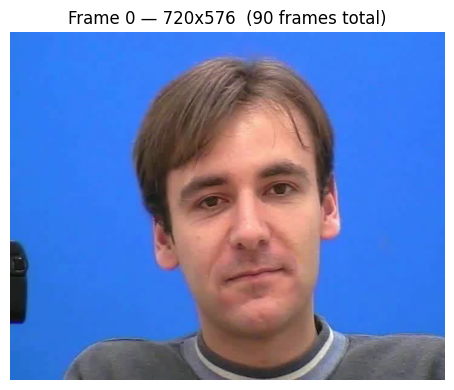

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from exordium import FIXTURE_DIR
from exordium.video.core.io import get_video_metadata, load_video

video_path = FIXTURE_DIR / "video" / "talking_short.mp4"
meta = get_video_metadata(video_path)
print(f"Video : {video_path.name}")
print(
    f"Frames: {meta['num_frames']} @ {meta['fps']:.1f} fps  "
    f"{meta['width']}x{meta['height']}  {meta['duration']:.2f}s"
)

frames_t, fps = load_video(video_path)  # (T, 3, H, W) uint8
frames_np = frames_t.permute(0, 2, 3, 1).numpy()  # (T, H, W, 3) uint8
T = frames_t.shape[0]
print(f"frames_t : {tuple(frames_t.shape)}  dtype={frames_t.dtype}")

plt.figure(figsize=(6, 4))
plt.imshow(frames_np[0])
plt.title(f"Frame 0 — {meta['width']}x{meta['height']}  ({T} frames total)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Load models

In [13]:
from exordium.video.face.blink import BlinkDenseNet121
from exordium.video.face.detector.yolo11 import YoloFace11Detector
from exordium.video.face.landmark.constants import FACEMESH_REGION_COLORS
from exordium.video.face.landmark.facemesh import (
    FaceMeshWrapper,
    crop_eye_regions,
    visualize_landmarks,
)

detector = YoloFace11Detector(device_id=None, conf=0.7)
facemesh = FaceMeshWrapper(min_detection_confidence=0.5)
blink_model = BlinkDenseNet121(device_id=None)

2026-03-23 11:49:23 INFO YoloFace11Detector loaded 'yolo11n-pose_widerface' on cpu (conf=0.7).
W0000 00:00:1774262963.114348 3328926 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774262963.117214 3328926 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1774262963.118090 3328929 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774262963.124211 3328929 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-03-23 11:49:23 INFO MediaPipe FaceMesh loaded.
2026-03-23 11:49:23 INFO Weights are loaded from /Users/fodorad/.cache/torch/hub/checkpoints/blink/densenet121-union-64.pt


---
## Step 1 — Face detection

YOLO11: 1 face  score=0.886  bb=[261, 121, 514, 496]
face_crop shape: (3, 486, 486)


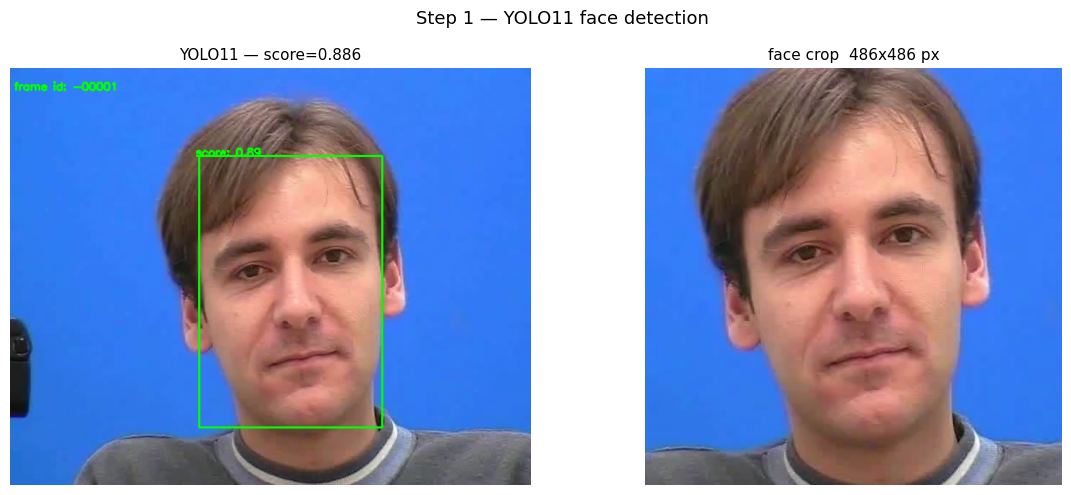

In [14]:
import cv2

from exordium.video.core.detection import add_detections_to_frame

sample_id = 0
sample_np = frames_np[sample_id]  # (H, W, 3)

dets = detector.detect_image(sample_np)
det = max(dets, key=lambda d: d.score)
face_crop = det.crop(square=True, extra_space=1.3)  # (3, H', W') uint8

print(f"YOLO11: {len(dets)} face  score={det.score:.3f}  bb={[int(v) for v in det.bb_xyxy]}")
print(f"face_crop shape: {tuple(face_crop.shape)}")

frame_bgr = add_detections_to_frame(list(dets), frame=None)
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(frame_rgb)
axes[0].set_title(f"YOLO11 — score={det.score:.3f}", fontsize=11)
axes[0].axis("off")
axes[1].imshow(face_crop.permute(1, 2, 0).numpy())
axes[1].set_title(f"face crop  {face_crop.shape[1]}x{face_crop.shape[2]} px", fontsize=11)
axes[1].axis("off")
plt.suptitle("Step 1 — YOLO11 face detection", fontsize=13)
plt.tight_layout()
plt.show()

## Step 2 — FaceMesh 478-point landmarks

FaceMesh: 478 landmarks  min=109.7  max=428.3


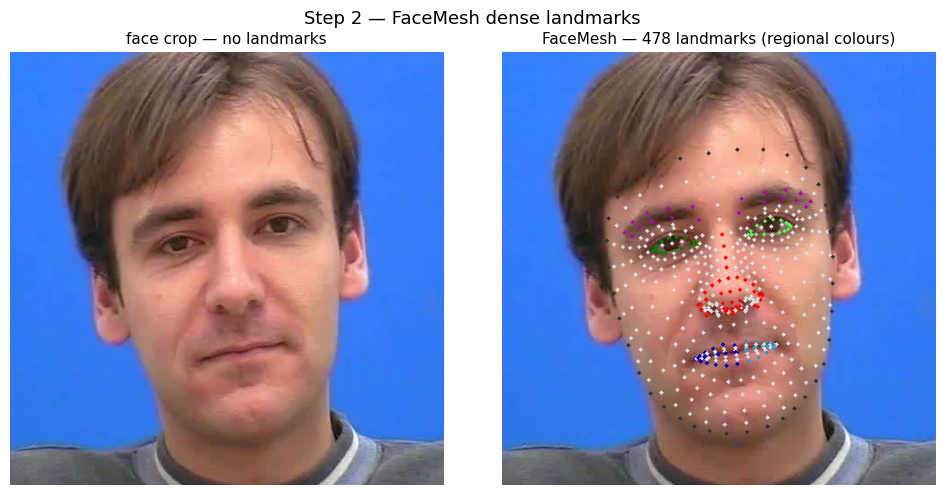

In [15]:
lmks_list = facemesh([face_crop])
lmks = lmks_list[0]  # (478, 2) float32 tensor
print(f"FaceMesh: {lmks.shape[0]} landmarks  min={lmks.min():.1f}  max={lmks.max():.1f}")

vis_mesh = visualize_landmarks(
    face_crop,
    lmks,
    colors=FACEMESH_REGION_COLORS,
    show_indices=False,
    radius=2,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(face_crop.permute(1, 2, 0).numpy())
axes[0].set_title("face crop — no landmarks", fontsize=11)
axes[0].axis("off")
axes[1].imshow(vis_mesh)
axes[1].set_title("FaceMesh — 478 landmarks (regional colours)", fontsize=11)
axes[1].axis("off")
plt.suptitle("Step 2 — FaceMesh dense landmarks", fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 — Eye region crops

`crop_eye_regions` computes the mean centroid of the 16 `RIGHT_EYE` / `LEFT_EYE`
FaceMesh indices per eye and sets `bb_size = int(inter_eye_distance x scale)`.
The result is a square crop that preserves the original pixel aspect ratio.

right_eye: (3, 110, 110)  left_eye: (3, 110, 110)


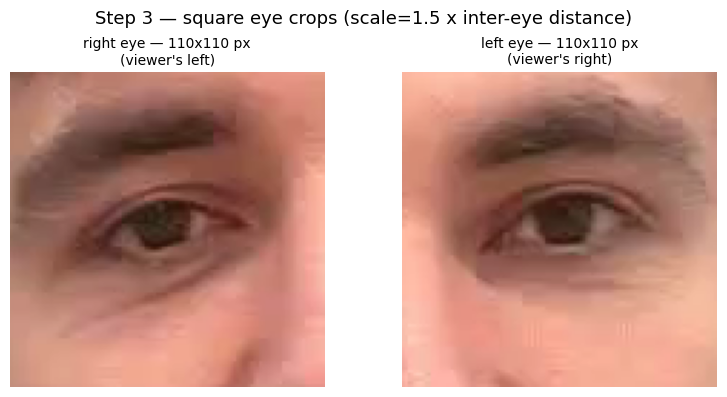

In [16]:
eyes = crop_eye_regions(face_crop, lmks, scale=1.0)
right_eye = eyes["eye_region_right"]  # (3, bb, bb) — subject's right, viewer's left
left_eye = eyes["eye_region_left"]  # (3, bb, bb) — subject's left, viewer's right

print(f"right_eye: {tuple(right_eye.shape)}  left_eye: {tuple(left_eye.shape)}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(right_eye.permute(1, 2, 0).numpy())
axes[0].set_title(
    f"right eye — {right_eye.shape[1]}x{right_eye.shape[2]} px\n(viewer's left)",
    fontsize=10,
)
axes[0].axis("off")
axes[1].imshow(left_eye.permute(1, 2, 0).numpy())
axes[1].set_title(
    f"left eye — {left_eye.shape[1]}x{left_eye.shape[2]} px\n(viewer's right)",
    fontsize=10,
)
axes[1].axis("off")
plt.suptitle("Step 3 — square eye crops (scale=1.5 x inter-eye distance)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Blink detection on all frames

`detect_video` runs YOLO11 on every frame.  For each frame that has a detection
the 5-pt YOLO11 keypoints are padded to the 6-pt format expected by
`predict_pipeline`, which then crops the eye regions and runs `BlinkDenseNet121`.

In [17]:
video_dets = detector.detect_video(video_path)

valid_frame_ids = []
valid_frames_np = []
valid_kp6 = []

for frame_id, fd in enumerate(video_dets):
    if not fd.detections:
        continue
    d = max(fd.detections, key=lambda x: x.score)
    kp5 = d.landmarks.float().numpy()  # (5, 2) — YOLO11 keypoints
    kp6 = np.vstack([kp5, kp5[-1:]])  # (6, 2) — pad with dummy 6th point
    valid_frame_ids.append(frame_id)
    valid_frames_np.append(frames_np[frame_id])
    valid_kp6.append(kp6)

all_frames_np = np.stack(valid_frames_np)  # (N, H, W, 3)
all_kp6 = np.stack(valid_kp6)  # (N, 6, 2)

l_state, r_state, l_valid, r_valid = blink_model.predict_pipeline(all_frames_np, all_kp6)

N = len(valid_frame_ids)
print(f"Frames with detection : {N} / {T}")
print(f"l_state: {tuple(l_state.shape)}  range=[{l_state.min():.3f}, {l_state.max():.3f}]")
print(f"r_state: {tuple(r_state.shape)}  range=[{r_state.min():.3f}, {r_state.max():.3f}]")

Frames with detection : 90 / 90
l_state: (90,)  range=[0.001, 0.985]
r_state: (90,)  range=[0.000, 0.957]


## Frame-wise blink score plot

Score > 0.5 (dashed red line) → eye classified as **closed**.

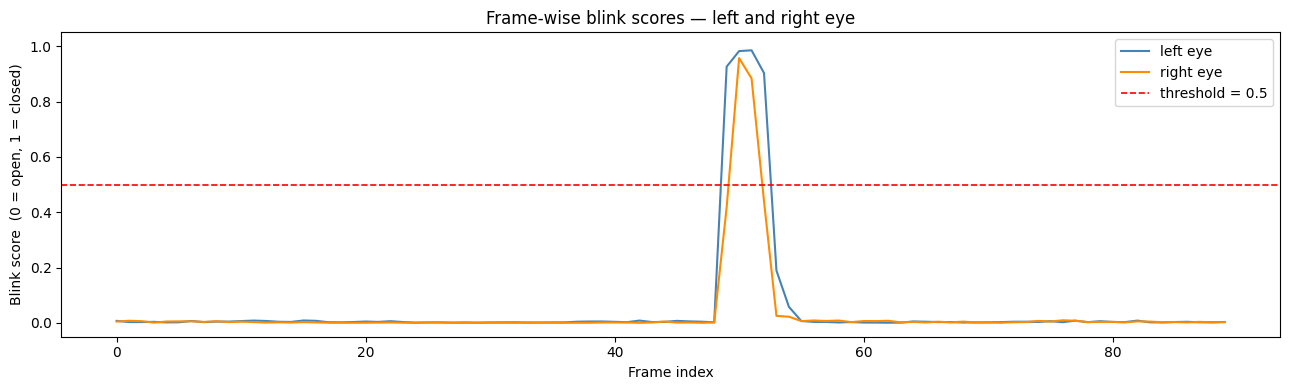

In [18]:
THRESHOLD = 0.5

# Build per-frame score arrays — NaN where no detection
l_scores = np.full(T, np.nan)
r_scores = np.full(T, np.nan)
for i, fid in enumerate(valid_frame_ids):
    l_scores[fid] = l_state[i].item()
    r_scores[fid] = r_state[i].item()

frame_idx = np.arange(T)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(frame_idx, l_scores, label="left eye", color="steelblue", linewidth=1.5)
ax.plot(frame_idx, r_scores, label="right eye", color="darkorange", linewidth=1.5)
ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.2, label=f"threshold = {THRESHOLD}")
ax.set_xlabel("Frame index")
ax.set_ylabel("Blink score  (0 = open, 1 = closed)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Frame-wise blink scores — left and right eye")
ax.legend()
plt.tight_layout()
plt.show()

## Example eye patches — open / in-between / closed

`predict_frame(..., return_patches=True)` re-runs inference on a single frame
and returns the 64×64 eye patch crops alongside the scores.

Open      : frame  29  avg_score=0.001
In-between: frame  52  avg_score=0.671
Closed    : frame  50  avg_score=0.970


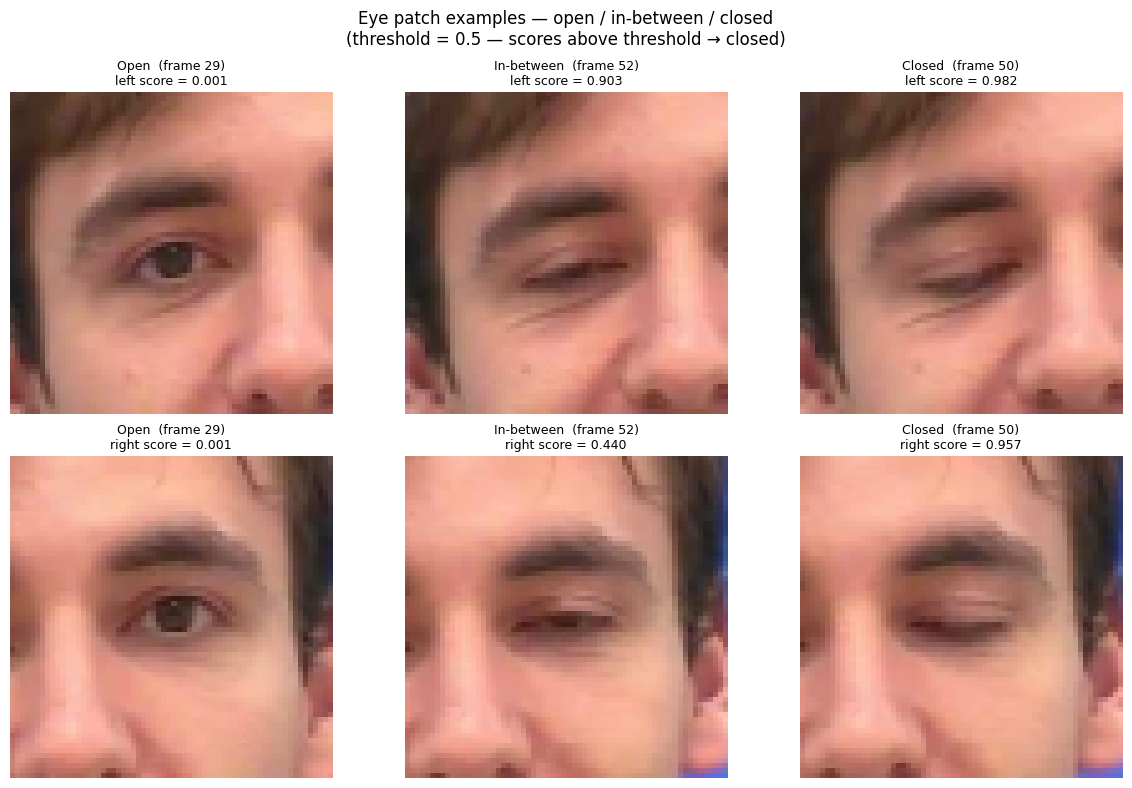

In [19]:
avg_scores = np.array([(l_scores[fid] + r_scores[fid]) / 2 for fid in valid_frame_ids])

open_local = int(np.argmin(avg_scores))
closed_local = int(np.argmax(avg_scores))
inbetween_local = int(np.argmin(np.abs(avg_scores - THRESHOLD)))

open_fid = valid_frame_ids[open_local]
closed_fid = valid_frame_ids[closed_local]
inbetween_fid = valid_frame_ids[inbetween_local]

print(f"Open      : frame {open_fid:3d}  avg_score={avg_scores[open_local]:.3f}")
print(f"In-between: frame {inbetween_fid:3d}  avg_score={avg_scores[inbetween_local]:.3f}")
print(f"Closed    : frame {closed_fid:3d}  avg_score={avg_scores[closed_local]:.3f}")


def get_patches(local_idx):
    fid = valid_frame_ids[local_idx]
    kp6 = all_kp6[local_idx]
    frm = frames_np[fid]
    l_s, r_s, l_v, r_v, l_patch, r_patch = blink_model.predict_frame(frm, kp6, return_patches=True)
    return l_s, r_s, l_patch, r_patch


open_ls, open_rs, open_lp, open_rp = get_patches(open_local)
inbet_ls, inbet_rs, inbet_lp, inbet_rp = get_patches(inbetween_local)
closed_ls, closed_rs, closed_lp, closed_rp = get_patches(closed_local)

col_titles = [
    f"Open  (frame {open_fid})",
    f"In-between  (frame {inbetween_fid})",
    f"Closed  (frame {closed_fid})",
]
left_patches = [open_lp, inbet_lp, closed_lp]
right_patches = [open_rp, inbet_rp, closed_rp]
left_scores = [open_ls, inbet_ls, closed_ls]
right_scores = [open_rs, inbet_rs, closed_rs]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col in range(3):
    axes[0, col].imshow(left_patches[col])
    axes[0, col].set_title(
        f"{col_titles[col]}\nleft score = {left_scores[col]:.3f}",
        fontsize=9,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(right_patches[col])
    axes[1, col].set_title(
        f"{col_titles[col]}\nright score = {right_scores[col]:.3f}",
        fontsize=9,
    )
    axes[1, col].axis("off")

for row, label in enumerate(["Left eye", "Right eye"]):
    axes[row, 0].set_ylabel(label, rotation=90, fontsize=10, labelpad=5)

plt.suptitle(
    "Eye patch examples — open / in-between / closed\n"
    "(threshold = 0.5 — scores above threshold → closed)",
    fontsize=12,
)
plt.tight_layout()
plt.show()